In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/nibabies_qc.tsv', sep='\t')
df = df.sort_values(by='Age months')

In [3]:
qc_labels = {1: 'Excellent', 2: 'Acceptable', 3: 'Poor'}
dot_size = 140
label_size = 14

def plot_reviews(ax, method):
    reviewer1 = f'{method} 1'
    reviewer2 = f'{method} 2'
    
    qc_agree = df[reviewer1] == df[reviewer2]

    # Agree
    ax.scatter(
        df[qc_agree][reviewer1],
        df[qc_agree]['Age months'], 
        c='blue',
        marker='o',
        edgecolor='black',
        label='Same Score',
        s=dot_size,
    )

    # Disagree
    for idx in df[~qc_agree].index:
        score_1 = df.loc[idx, reviewer1]
        score_2 = df.loc[idx, reviewer2]
        avg_score = (score_1 + score_2) / 2
        age = df.loc[idx, 'Age months']
        ax.scatter(avg_score, age, c='orange', marker='o', edgecolor='none', s=dot_size)
        ax.plot([score_1, avg_score], [age, age], 'orange', linestyle='-')
        ax.plot([avg_score, score_2], [age, age], 'orange', linestyle='-')

    ax.set_title(method.title(), fontsize=14)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels([qc_labels[1], qc_labels[2], qc_labels[3]])
    ax.set_ylim(-1, 41)
    ax.invert_yaxis()
    ax.set_xlim(0.75, 3.25)

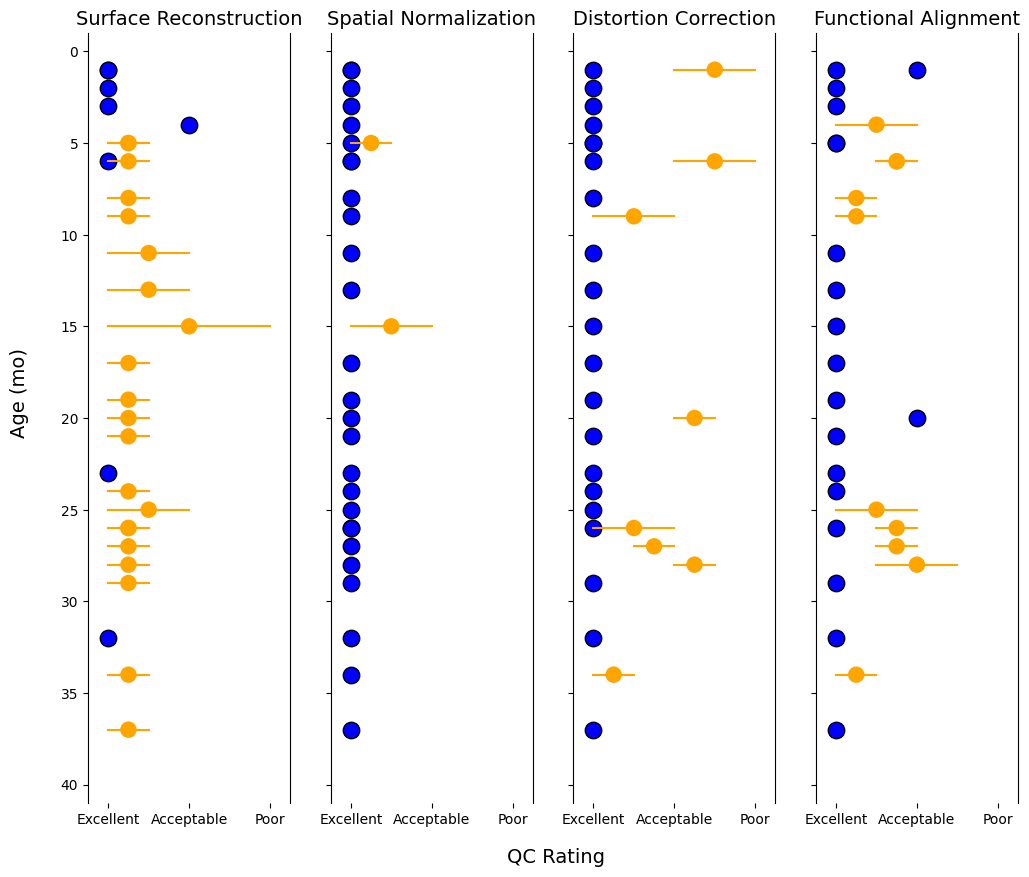

In [4]:
fig, axs = plt.subplots(1, 4, figsize=(12, 10), gridspec_kw={'wspace': 0.2})

plot_reviews(axs[0], 'Surface reconstruction')
plot_reviews(axs[1], 'Spatial normalization')
plot_reviews(axs[2], 'Distortion correction')
plot_reviews(axs[3], 'Functional alignment')

fig.text(0.06, 0.52, 'Age (mo)', va='center', rotation='vertical', fontsize=14)
fig.text(0.515, 0.05, 'QC Rating', ha='center', fontsize=14)

for i, ax in enumerate(axs):
    if i > 0:
        ax.set_yticklabels([])
        
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    

plt.savefig('fig4.png', bbox_inches='tight')
plt.show()